# Task 1 —Data Loading & Exploration


In [4]:
import pandas as pd

In [5]:
# Load the dataset
df=pd.read_csv("Housing.csv")

In [6]:
# Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
# Check how many rows and columns are there
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [8]:
# data type of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
# Identify the target column and the feature columns
target="price"
features=df.columns.drop(target)

print("Target Column:",target)
print("Feature Columns:",features)


Target Column: price
Feature Columns: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
# Check for missing values in each column
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [11]:
# statistical summary of the numeric columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# task 2— Data Cleaning

In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [14]:
df.select_dtypes(include="object").columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [15]:
#Convert yes/no categorical columns into numeric form (1/0)
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df[yes_no_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [16]:
# One-hot encode 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [17]:
# check every column is now numeric
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


# task 3—Model Building

In [18]:
#Features (X) and Target (y)
X=df.drop("price",axis=1)
y=df["price"]

In [19]:
# Train-test split (80/20)
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 436
Testing rows: 109


In [20]:
# train Linear Regression mode
from sklearn.linear_model import LinearRegression

lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

y_pred_lr=lr_model.predict(X_test)

In [21]:
# Evaluate Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae_lr=mean_absolute_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr=r2_score(y_test,y_pred_lr)

print("Linear Regression Results")
print("MAE:",mae_lr)
print("RMSE:",rmse_lr)
print("R2 Score:",r2_lr)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153185


In [22]:
# Train a Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

In [23]:
# Evaluate Random Forest
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf=r2_score(y_test,y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2 Score:",r2_rf)

Random Forest Regressor Results
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


In [24]:
# Compare both models
print("Model Comparison")
print("-"*55)
print(f"Linear Regression:MAE{mae_lr:2f},RMSE:{rmse_lr:2f},r2:{r2_lr:4f}")
print(f"Random Forest:MAE:{mae_rf:2f},RMSE:{rmse_rf:2f},r2:{r2_rf:4f}")

Model Comparison
-------------------------------------------------------
Linear Regression:MAE970043.403920,RMSE:1324506.960091,r2:0.652924
Random Forest:MAE:1022560.052752,RMSE:1401496.842538,r2:0.611402


# task 4 — Visualizatio

# Chart1: House Price Distibution


In [25]:
import os
os.makedirs("charts", exist_ok=True)

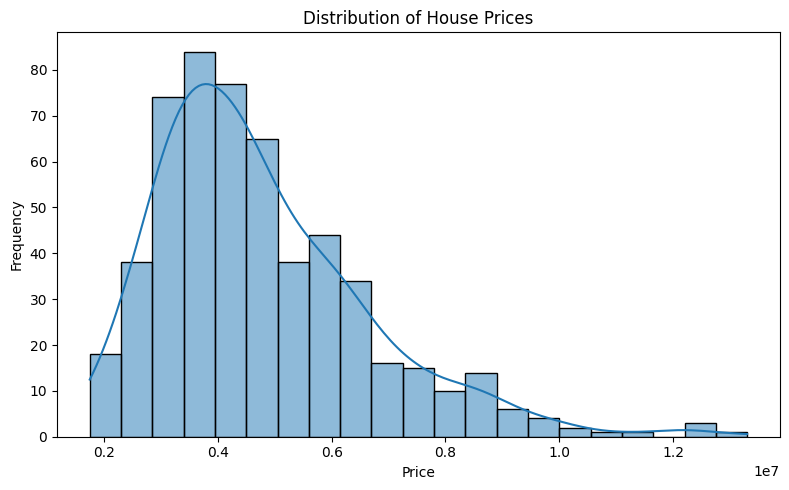

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150)
plt.show()

# Chart 2:Correlation Heatmap

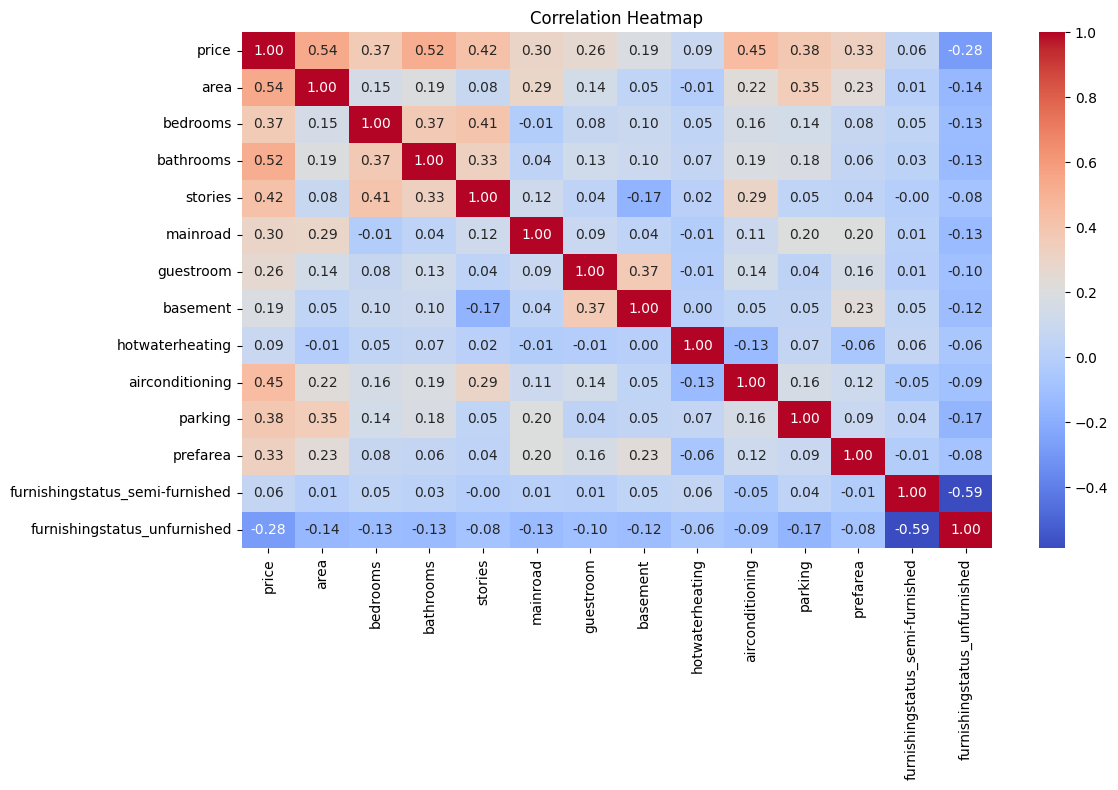

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150)
plt.show()

# Chart:3 Actual vs Predicted Price(best model)

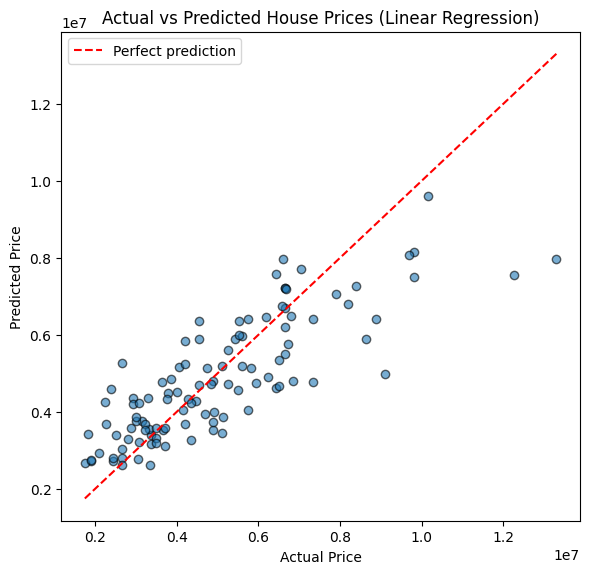

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150)
plt.show()

## Task 5 — Insights & Summary

Across the dataset, **area** emerged as the most influential factor affecting house prices, followed closely by the **number of bathrooms** and the presence of **air conditioning**. Other variables such as the number of stories, parking availability, and preferred location also contributed positively to price variation, while furnishing status showed a consistent effect, with fully furnished houses generally commanding higher prices compared to semi-furnished or unfurnished ones.

In terms of model performance, the **Linear Regression model performed best**, achieving an **R² score of 0.6529**, indicating that it explained approximately **65% of the variance in house prices**. It also recorded a relatively low error with an **MAE of ~₹9.7 lakh** and an **RMSE of ~₹13.2 lakh**, making it a reasonably reliable model for approximate price estimation. In contrast, the **Random Forest Regressor performed slightly worse**, with an **R² score of 0.6114**, higher MAE (~₹10.2 lakh), and higher RMSE (~₹14.0 lakh), suggesting that it did not generalize as effectively on this relatively small dataset and may have slightly overfitted complex patterns.

A notable observation from the analysis was that the simpler Linear Regression model outperformed the more complex Random Forest model, which indicates that the relationship between house features and price in this dataset is largely linear rather than highly non-linear. Additionally, the dataset size may not have been sufficient for ensemble methods to show their full advantage.

From a business perspective, real estate companies should primarily focus on **property area and bathroom count** as the strongest pricing indicators. Furthermore, strategic upgrades such as adding air conditioning and improving furnishing quality can significantly enhance perceived property value and improve market competitiveness.
